In [1]:
import random
from datetime import date
from datetime import datetime
import string
import pandas as pd
import numpy as np
from time import time
from IPython.display import display,Markdown

from faker import Faker
fake = Faker()

import matplotlib.pyplot as plt

In [2]:
zip_density = pd.read_csv('zip_density.csv')
zip_density['Zip'] = zip_density['Zip'].astype(str).str.zfill(5)

In [3]:
def generate_samples(df, sample_size=100):
    sample_index = np.random.choice(
        df.index,
        size=sample_size,
        replace=True,
        p=df['weight'].values
    )
    sample = df.loc[sample_index]
    sample['population'] = 1
    sample = sample.drop(columns=['weight'])
    return sample.reset_index(drop=True)

In [4]:
total_population = zip_density.population.sum()
total_dist = zip_density.groupby('State').population.sum() / total_population

In [5]:
sample_size = 150_000

In [6]:
start = time()
sample = generate_samples(zip_density, sample_size=sample_size)
sample.columns = sample.columns.str.lower()
sample_population = sample.population.sum()
sample_dist = sample.groupby('state').population.sum() / sample_population
dur1 = time() - start
print(f"{dur1:0.6f}")

0.042439


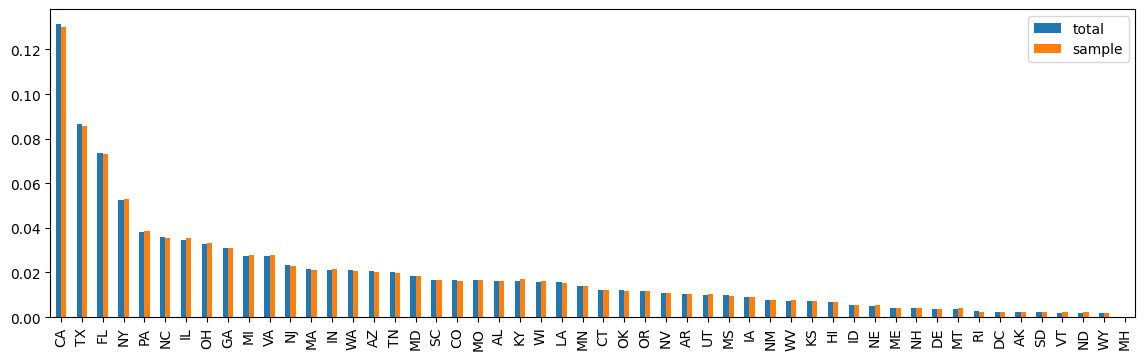

In [7]:
""" Verify sample distribution aligns with zip density
"""
d = pd.concat([total_dist.rename('total'), 
               sample_dist.rename('sample'),
               # sample2_dist.rename('sample2')
              ],axis=1).fillna(0).sort_values('total', ascending=False)
d.plot.bar(figsize=(14,4))
plt.show()
# d.style.format("{:0.3%}")

In [8]:
chars = string.ascii_lowercase + string.digits + '_.-'
def gen_email(r):
    first_name = r.first_name.lower()[:random.randint(1,15)] if random.random() < 0.3 else r.first_name.lower()
    last_name = r.last_name.lower()[:random.randint(5,30)] if random.random() < 0.5 else r.last_name.lower()
    separator = random.choice('_.-') if random.random() < 0.75 and len(first_name) > 0 else ''
    garbage = ''.join(random.choices(chars, k=random.randint(0,5))) if random.random() < 0.5 else ''
    domain = random.choices([fake.free_email_domain, fake.safe_domain_name, fake.domain_name],weights=[.6,.3,.2])[0]()
    return f"{first_name}{separator}{last_name}{garbage}@{domain}"

def make_email(x, seen=set()):
    response = []
    
    for r in x.itertuples():
        email = gen_email(r)
        if email not in seen:
            seen.add(email)
            response.append(email)
        else:
            new_email = gen_email(r)
            while new_email in seen:
                new_email = gen_email(r)
            seen.add(new_email)
            response.append(new_email)
        
    return response

dataset = sample.assign(
    street_address=lambda x: [fake.street_address() for i in range(x.shape[0])],
    first_name=lambda x: [fake.first_name() for i in range(x.shape[0])],
    last_name=lambda x: [fake.last_name() for i in range(x.shape[0])],
    email=make_email,
    address_id=lambda x: [f"addr_{fake.uuid4(cast_to=None).hex[:12]}" for r in range(x.shape[0])],
    customer_id=lambda x: [f"cust_{fake.uuid4(cast_to=None).hex[:12]}" for r in range(x.shape[0])],
    created_at=lambda x: [fake.date_time_between(start_date='-3y').strftime('%Y-%m-%dT%H:%M:%S+00:00') for r in range(x.shape[0])],
)


In [9]:
def cardinality_check(df):
    a = {}
    for col in df.columns:
        a[col] = len(df[col].unique()) / df.shape[0]
    return pd.Series(a, name='cardinality').to_frame()

In [10]:
cardinality_check(dataset)

,cardinality
zip,0.164493
city,0.070647
state,0.000340
county,0.011607
population,0.000007
street_address,0.999980
first_name,0.004600
last_name,0.006667
email,1.000000
address_id,1.000000


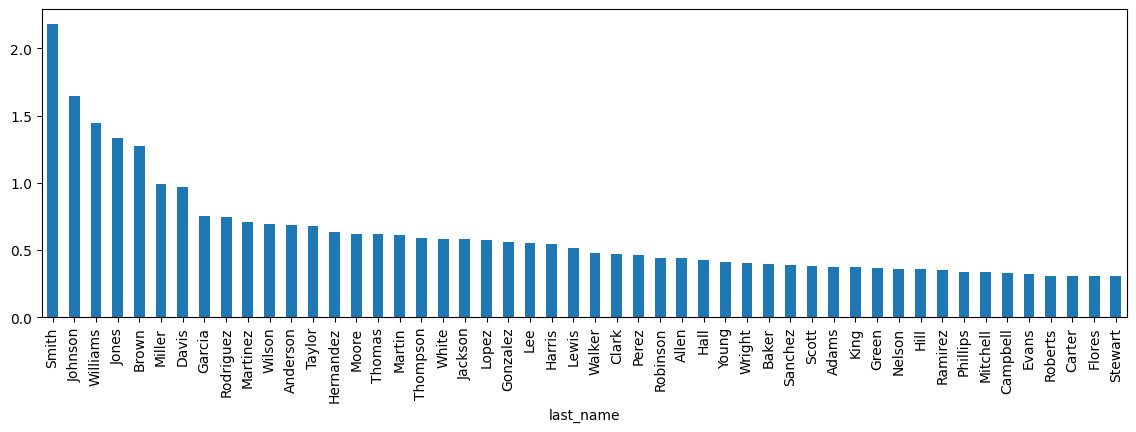

,weight
last_name,
Smith,2.182%
Johnson,1.649%
Williams,1.445%
Jones,1.331%
Brown,1.273%


In [11]:
field = 'last_name'
n = (50,5)
_ = dataset\
    .groupby(field, as_index=False).customer_id.count()\
    .assign(weight=lambda x: x.customer_id / dataset.shape[0] * 100)\
    .sort_values('customer_id', ascending=False)\
    .set_index(field)['weight'][:n[0]]   

_.plot.bar(figsize=(14,4))
plt.show()
_[:n[1]].to_frame().style.format("{:0.3f}%")

In [12]:
seen = set(dataset.email.to_list())

In [13]:
households = dataset.sample(frac=0.4).reset_index()
households["dup_count"] = np.random.choice(
    [0,1,2,3],
    size=len(households),
    p=[0.5, 0.3, 0.15, 0.05]
)
expanded = households.loc[households.index.repeat(households["dup_count"])]

households = pd.concat([households,expanded], ignore_index=True).assign(
    first_name=lambda x: [fake.first_name() for i in range(x.shape[0])],
    last_name=lambda x: [fake.last_name() if random.random() < 0.1 else r.last_name for r in x.itertuples()],
    email=lambda x: make_email(x, seen),
    customer_id=lambda x: [f"cust_{fake.uuid4(cast_to=None).hex[:12]}" for r in range(x.shape[0])],
    created_at=lambda x: [fake.date_time_between(start_date=datetime.fromisoformat(r.created_at)).strftime('%Y-%m-%dT%H:%M:%S+00:00') for r in x.itertuples()],
)

In [14]:
customers_addresses = pd.concat([dataset,households], ignore_index=True).drop(columns=['index','dup_count'])

In [15]:
print(f"{dataset.shape[0]}, {households.shape[0]}, {customers_addresses.shape[0]}")

150000, 104935, 254935


In [16]:
cardinality_check(customers_addresses)

,cardinality
zip,0.096785
city,0.041567
state,0.000200
county,0.006829
population,0.000004
street_address,0.588374
first_name,0.002707
last_name,0.003923
email,1.000000
address_id,0.588385


In [17]:
customer_fields = ['customer_id','first_name','last_name','email','address_id','created_at']
customers = customers_addresses[~customers_addresses.duplicated(subset=customer_fields, keep='first')].loc[:,customer_fields]
cardinality_check(customers)

,cardinality
customer_id,1.000000
first_name,0.002707
last_name,0.003923
email,1.000000
address_id,0.588385
created_at,0.998455


In [18]:
address_fields = ['address_id','street_address','city','state','zip']
addresses = customers_addresses[~customers_addresses.duplicated(subset=address_fields, keep='first')].loc[:,address_fields]\
    .assign(country='US').rename(columns={'zip':'postal_code'})
cardinality_check(addresses)

,cardinality
address_id,1.000000
street_address,0.999980
city,0.070647
state,0.000340
postal_code,0.164493
country,0.000007


## Products

In [19]:
import random
import string
import pandas as pd
from faker import Faker

fake = Faker()

# ---------------------------------------------------------
# 1. Expanded base product names (30–40 per category)
# ---------------------------------------------------------
PRODUCT_BASES = {
    "Electronics": [
        "Wireless Headphones", "Bluetooth Speaker", "Smartphone Case",
        "USB-C Cable", "Portable Charger", "LED Monitor", "Webcam",
        "Gaming Mouse", "Mechanical Keyboard", "Smartwatch",
        "Noise Cancelling Earbuds", "4K Action Camera", "WiFi Router",
        "External SSD", "Laptop Stand", "HDMI Switch", "Dash Cam",
        "Bluetooth Tracker", "VR Headset", "Smart Light Bulb",
        "Portable Projector", "Soundbar", "Graphics Tablet",
        "Gaming Controller", "Wireless Charger", "Microphone",
        "Studio Headphones", "Drone Camera", "Mini Tripod",
        "Bluetooth Adapter", "USB Hub", "Ergonomic Mouse"
    ],
    "Home & Kitchen": [
        "Stainless Steel Pan", "Electric Kettle", "Vacuum Cleaner",
        "Air Fryer", "Cutlery Set", "Coffee Grinder", "Water Filter",
        "Blender", "Toaster Oven", "Rice Cooker", "Food Storage Set",
        "Chef Knife", "Pressure Cooker", "Hand Mixer", "Dish Rack",
        "Slow Cooker", "Cast Iron Skillet", "Electric Griddle",
        "Stand Mixer", "Glass Bakeware Set", "Kitchen Scale",
        "Electric Can Opener", "Food Processor", "Immersion Blender",
        "Air Purifier", "Dehumidifier", "Space Heater",
        "Electric Wine Opener", "Knife Sharpener", "Salad Spinner"
    ],
    "Beauty & Personal Care": [
        "Moisturizing Cream", "Shampoo", "Conditioner",
        "Face Serum", "Body Lotion", "Hair Dryer",
        "Beard Trimmer", "Electric Toothbrush", "Sunscreen",
        "Lip Balm", "Facial Cleanser", "Makeup Remover",
        "Face Mask", "Body Scrub", "Hair Straightener",
        "Curling Iron", "Nail Polish Set", "Beard Oil",
        "Aftershave Balm", "Anti-Aging Cream", "Eye Cream",
        "Hair Mousse", "Dry Shampoo", "Face Toner",
        "Hand Cream", "Foot Cream", "Bath Salts"
    ],
    "Sports & Outdoors": [
        "Yoga Mat", "Running Shoes", "Camping Tent",
        "Hiking Backpack", "Water Bottle", "Dumbbell Set",
        "Trekking Poles", "Sleeping Bag", "Cycling Helmet",
        "Fishing Rod", "Portable Cooler", "Kayak Paddle",
        "Camping Stove", "Climbing Rope", "Trail Running Vest",
        "Binoculars", "Hiking Boots", "Inflatable Kayak",
        "Camping Lantern", "Portable Hammock", "Snow Goggles",
        "Ski Gloves", "Swim Goggles", "Tennis Racket",
        "Pickleball Paddle", "Soccer Ball", "Basketball"
    ],
    "Toys & Games": [
        "Building Blocks", "Board Game", "Puzzle Set",
        "RC Car", "Dollhouse", "Action Figure",
        "Science Kit", "Plush Toy", "Marble Run",
        "Train Set", "Art Kit", "STEM Robot",
        "Kite Set", "Magic Kit", "Water Gun",
        "Foam Dart Blaster", "Play Kitchen", "Toy Drum Set",
        "Remote Helicopter", "Mini Drone", "Card Game",
        "Strategy Game", "Toddler Learning Blocks"
    ],
    "Office Supplies": [
        "Notebook", "Ballpoint Pen", "Desk Organizer",
        "Stapler", "Mouse Pad", "Office Chair",
        "Standing Desk", "Paper Shredder", "Whiteboard",
        "Fountain Pen", "File Cabinet", "Label Maker",
        "Desk Lamp", "Monitor Stand", "Keyboard Tray",
        "Document Scanner", "Desk Mat", "Sticky Notes",
        "Highlighter Set", "Clip Dispenser", "Desk Clock"
    ]
}

# ---------------------------------------------------------
# 2. Expanded brand list (30+ synthetic brands)
# ---------------------------------------------------------
BRANDS = [
    "Apex", "NovaTech", "BluePeak", "UrbanPro", "Silverline",
    "OmniGear", "EverBright", "Zenith", "CoreWorks", "Peakstone",
    "BrightLeaf", "Hyperion", "NorthStar", "FlexiCo", "RedRiver",
    "SkyForge", "IronClad", "PureWave", "EcoFlow", "TrueNorth",
    "PrimeEdge", "VoltX", "GearLab", "SummitPro", "CrystalTech",
    "MetroLine", "UltraCore", "BrightPath", "NextPhase", "OptiMax"
]

# ---------------------------------------------------------
# 3. Expanded modifiers (colors, materials, sizes, etc.)
# ---------------------------------------------------------
COLORS = [
    "Black", "White", "Blue", "Red", "Green", "Gray", "Silver", "Gold",
    "Navy", "Charcoal", "Rose", "Teal", "Beige"
]

EDITIONS = [
    "Pro", "XL", "Mini", "Plus", "Lite", "Max", "Ultra", "SE", "Prime"
]

PACKS = [
    "2-Pack", "3-Pack", "4-Pack", "5-Pack", "6-Pack", "10-Pack"
]

MATERIALS = [
    "Stainless Steel", "Carbon Fiber", "Bamboo", "Aluminum",
    "Titanium", "Glass", "Recycled Plastic"
]

SIZES = [
    "Small", "Medium", "Large", "Extra Large", "Compact", "Travel Size"
]

ADJECTIVES = [
    "Premium", "Advanced", "Eco-Friendly", "Portable", "Heavy-Duty",
    "Lightweight", "Ergonomic", "Smart", "Rechargeable", "Wireless"
]

MODEL_CHARS = string.ascii_uppercase + string.digits

def random_model():
    return "".join(random.choices(MODEL_CHARS, k=random.randint(3, 6)))

# ---------------------------------------------------------
# 4. Build a highly varied product name
# ---------------------------------------------------------
def generate_product_name(category):
    base = random.choice(PRODUCT_BASES[category])
    brand = random.choice(BRANDS)

    modifier = random.choice([
        "",
        random.choice(COLORS),
        random.choice(EDITIONS),
        random.choice(PACKS),
        random.choice(MATERIALS),
        random.choice(SIZES),
        random.choice(ADJECTIVES),
        f"Model {random_model()}",
        f"{random.choice(COLORS)} {random.choice(EDITIONS)}",
        f"{random.choice(ADJECTIVES)} {random.choice(SIZES)}",
        f"{random.choice(EDITIONS)} Model {random_model()}",
        f"{random.choice(MATERIALS)} Edition",
    ])

    name = f"{brand} {base}"
    if modifier:
        name += f" {modifier}"

    return name

# ---------------------------------------------------------
# 5. SKU generator
# ---------------------------------------------------------
def generate_sku(category):
    prefix = ''.join(word[0] for word in category.split()).upper()
    rand = ''.join(random.choices(string.ascii_uppercase + string.digits, k=6))
    return f"{prefix}-{rand}"

# ---------------------------------------------------------
# 6. Full product generator
# ---------------------------------------------------------
def generate_product():
    category = random.choice(list(PRODUCT_BASES.keys()))
    name = generate_product_name(category)

    price = round(random.uniform(5, 300), 2)
    cost_price = round(price * random.uniform(0.45, 0.75), 2)

    return {
        "product_id": f"prod_{fake.uuid4(cast_to=None).hex[:12]}",
        "sku": generate_sku(category),
        "name": name,
        "category": category,
        "price": price,
        "cost_price": cost_price
    }

# ---------------------------------------------------------
# 7. Generate catalog
# ---------------------------------------------------------
def generate_catalog(n=5000):
    return pd.DataFrame(generate_product() for _ in range(n))

products = generate_catalog(25000)



In [20]:
cardinality_check(products)

,cardinality
product_id,1.00000
sku,0.99996
name,0.96840
category,0.00024
price,0.67564
cost_price,0.56180


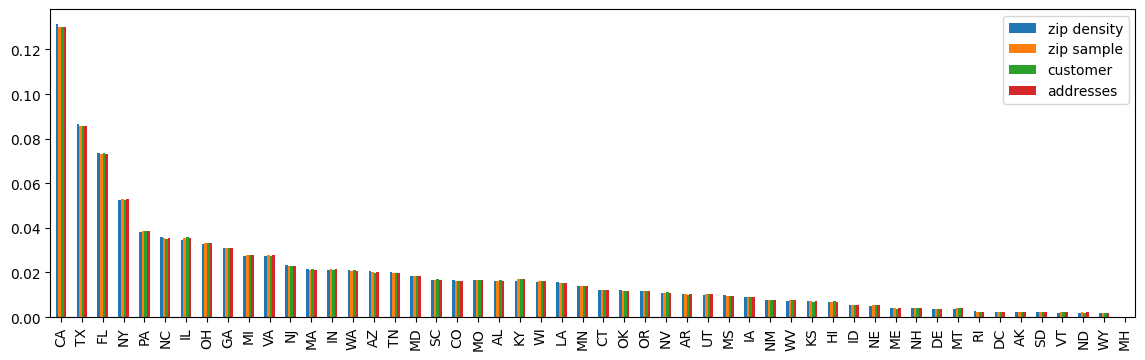

In [21]:
total_population = zip_density.population.sum()
total_dist = zip_density.groupby('State').population.sum() / total_population

sample_population = sample.population.sum()
sample_dist = sample.groupby('state').population.sum() / sample_population

customer_population = customers_addresses.shape[0]
customer_dist = customers_addresses.groupby('state').customer_id.count() / customer_population

addresses_population = addresses.shape[0]
addresses_dist = addresses.groupby('state').address_id.count() / addresses_population


d = pd.concat([total_dist.rename('zip density'), 
               sample_dist.rename('zip sample'),
               customer_dist.rename('customer'),
               addresses_dist.rename('addresses'),
              ],axis=1).fillna(0).sort_values('zip density', ascending=False)
d.plot.bar(figsize=(14,4))
plt.show()
# d.style.format("{:0.3%}")

In [22]:
print(f"""
Customers: {customers.shape[0]:>10,.0f}
Addresses: {addresses.shape[0]:>10,.0f}
Products:  {products.shape[0]:>10,.0f}
""")


Customers:    254,935
Addresses:    150,000
Products:      25,000



In [23]:
assert addresses['address_id'].is_unique, "address_id is not unique"
assert customers['customer_id'].is_unique, "customer_id is not unique"
assert customers['email'].is_unique, "email is not unique"
assert products['product_id'].is_unique, "product_id is not unique"

In [24]:
customers.to_csv('customers_testing.csv', index=False)
addresses.to_csv('addresses_testing.csv', index=False)
products.to_csv('products_testing.csv', index=False)

In [25]:
tables = ['customers','addresses','products']
for table in tables:
    d = globals()[table]
    display(Markdown(f"### {table}"),Markdown('\n'.join(f"- `{name}` ({value})" for name,value in d.dtypes.items())))


### customers

- `customer_id` (str)
- `first_name` (str)
- `last_name` (str)
- `email` (str)
- `address_id` (str)
- `created_at` (str)

### addresses

- `address_id` (str)
- `street_address` (str)
- `city` (str)
- `state` (str)
- `postal_code` (str)
- `country` (str)

### products

- `product_id` (str)
- `sku` (str)
- `name` (str)
- `category` (str)
- `price` (float64)
- `cost_price` (float64)